In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
#%matplotlib notebook
plt.rcParams["figure.figsize"] = (10,6)
import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix
from sklearn.metrics import plot_roc_curve, plot_precision_recall_curve, roc_auc_score, auc, roc_curve
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv("/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")
data = df = pd.read_csv("/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")

In [4]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.000,0,1,Yes,Private,Urban,228.690,36.600,formerly smoked,1
1,51676,Female,61.000,0,0,Yes,Self-employed,Rural,202.210,NaN,never smoked,1
2,31112,Male,80.000,0,1,Yes,Private,Rural,105.920,32.500,never smoked,1
3,60182,Female,49.000,0,0,Yes,Private,Urban,171.230,34.400,smokes,1
4,1665,Female,79.000,1,0,Yes,Self-employed,Rural,174.120,24.000,never smoked,1


In [5]:
df.shape

(5110, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [7]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000,5110.000,5110.000,5110.000,5110.000,4909.000,5110.000
mean,36517.829,43.227,0.097,0.054,106.148,28.893,0.049
std,21161.722,22.613,0.297,0.226,45.284,7.854,0.215
min,67.000,0.080,0.000,0.000,55.120,10.300,0.000
25%,17741.250,25.000,0.000,0.000,77.245,23.500,0.000
50%,36932.000,45.000,0.000,0.000,91.885,28.100,0.000
75%,54682.000,61.000,0.000,0.000,114.090,33.100,0.000
max,72940.000,82.000,1.000,1.000,271.740,97.600,1.000


In [8]:
df = df.drop('id',axis=1)

In [9]:
df.stroke.value_counts(normalize=True)

0   0.951
1   0.049
Name: stroke, dtype: float64

In [10]:
df.age.sort_values()

3295    0.080
1614    0.080
3618    0.160
4021    0.160
3968    0.160
        ...  
4590   82.000
4094   82.000
2341   82.000
4716   82.000
187    82.000
Name: age, Length: 5110, dtype: float64

In [11]:
round(df.age.sort_values())[:100]

3295   0.000
1614   0.000
3618   0.000
4021   0.000
3968   0.000
        ... 
1101   2.000
4006   2.000
1137   2.000
1758   2.000
913    2.000
Name: age, Length: 100, dtype: float64

In [12]:
df[df['stroke'] == 1]['age'].nsmallest(10)

162    1.320
245   14.000
182   32.000
118   38.000
133   38.000
49    39.000
210   39.000
228   39.000
31    42.000
79    43.000
Name: age, dtype: float64

Datamızı incelediğimiz zaman yaş sütununda yer alan verilerin tahminlerimizi saptıracak ölçüde 
anlamsız değerler içerdiğini görmekteyiz. Örneğin 'stroke' olan kişilerden yaşı en küçük olan 
10 kişiyi getirdiğimiz zaman 1.320 yaş ve 14.00 gibi yaşlar görüyoruz. Sonraki yaşların başlangıcı ise en yakın 32.00
olarak karşımıza çıkmaktadır. Bu datayı kullanarak daha anlamlı tahminler yapmak için 14 yaş ve altı herkesi drop
etmek yerinde olacaktır diye düşünüyorum.

In [13]:
df = df.drop(index = 3116)
# gender değişkeninde yer alan 'other' değerini drop ediyoruz. 

In [14]:
df = df[df['age'] >= 14]

In [15]:
df.shape
print(f"14 yaş ve altı kişiler düşünce {df.shape[0]} satır kaldı. {5110-df.shape[0]} tane satır düşmüş  olduk.")

14 yaş ve altı kişiler düşünce 4464 satır kaldı. 646 tane satır düşmüş  olduk.


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4464 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4464 non-null   object 
 1   age                4464 non-null   float64
 2   hypertension       4464 non-null   int64  
 3   heart_disease      4464 non-null   int64  
 4   ever_married       4464 non-null   object 
 5   work_type          4464 non-null   object 
 6   Residence_type     4464 non-null   object 
 7   avg_glucose_level  4464 non-null   float64
 8   bmi                4279 non-null   float64
 9   smoking_status     4464 non-null   object 
 10  stroke             4464 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 418.5+ KB


In [17]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4464.000,4464.000,4464.000,4464.000,4279.000,4464.000
mean,48.570,0.112,0.062,107.918,30.244,0.056
std,18.892,0.315,0.240,47.136,7.336,0.229
min,14.000,0.000,0.000,55.120,11.300,0.000
25%,33.000,0.000,0.000,77.460,25.100,0.000
50%,49.000,0.000,0.000,92.220,29.000,0.000
75%,63.000,0.000,0.000,115.913,34.000,0.000
max,82.000,1.000,1.000,271.740,97.600,1.000


In [18]:
data.smoking_status.value_counts()

never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: smoking_status, dtype: int64

In [19]:
df['stroke'].value_counts(normalize=True)*100

0   94.444
1    5.556
Name: stroke, dtype: float64

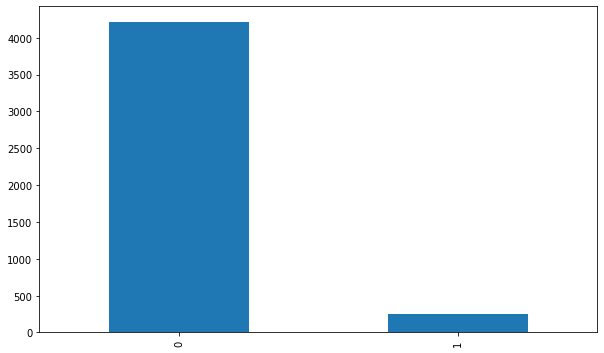

In [20]:
df['stroke'].value_counts().plot(kind = 'bar');

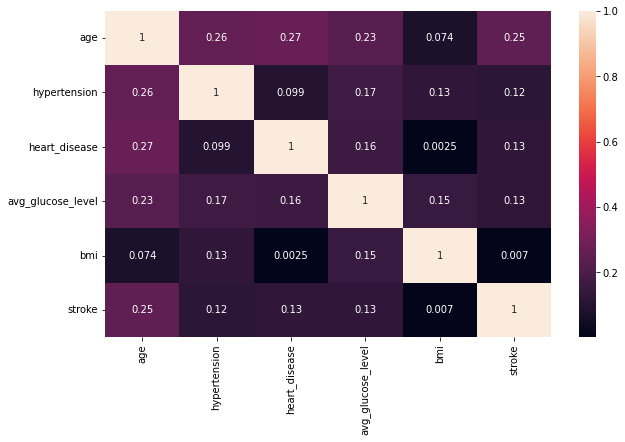

In [21]:
sns.heatmap(df.corr(),annot = True);

<AxesSubplot:xlabel='stroke', ylabel='age'>

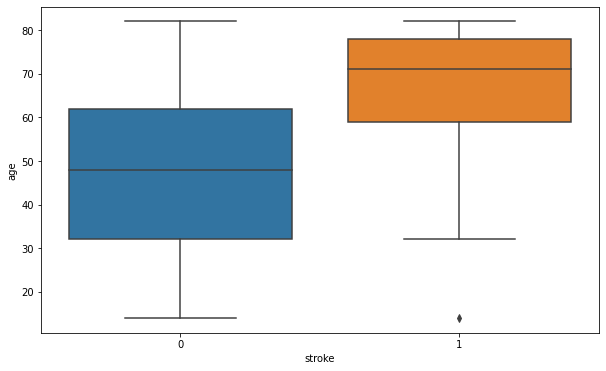

In [22]:
sns.boxplot(data = df, x = 'stroke', y = 'age')

In [23]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.000,0,1,Yes,Private,Urban,228.690,36.600,formerly smoked,1
1,Female,61.000,0,0,Yes,Self-employed,Rural,202.210,NaN,never smoked,1
2,Male,80.000,0,1,Yes,Private,Rural,105.920,32.500,never smoked,1
3,Female,49.000,0,0,Yes,Private,Urban,171.230,34.400,smokes,1
4,Female,79.000,1,0,Yes,Self-employed,Rural,174.120,24.000,never smoked,1


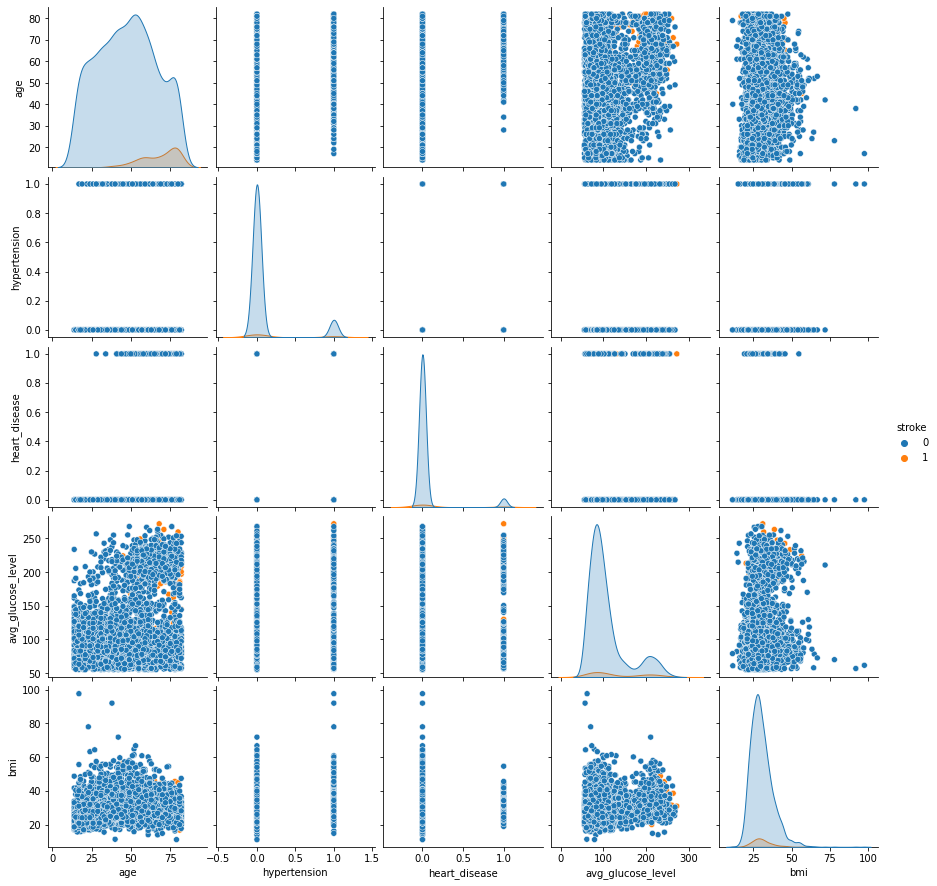

In [24]:
sns.pairplot(df,hue='stroke');

kategorik değişkenlerde yer alan değerleri scale edebilmek için
1 ve 0 haline getiriyoruz. 

In [25]:
df = pd.get_dummies(df, drop_first=True)
df

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.000,0,1,228.690,36.600,1,1,1,0,1,0,0,1,1,0,0
1,61.000,0,0,202.210,NaN,1,0,1,0,0,1,0,0,0,1,0
2,80.000,0,1,105.920,32.500,1,1,1,0,1,0,0,0,0,1,0
3,49.000,0,0,171.230,34.400,1,0,1,0,1,0,0,1,0,0,1
4,79.000,1,0,174.120,24.000,1,0,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,80.000,1,0,83.750,NaN,0,0,1,0,1,0,0,1,0,1,0
5106,81.000,0,0,125.200,40.000,0,0,1,0,0,1,0,1,0,1,0
5107,35.000,0,0,82.990,30.600,0,0,1,0,0,1,0,0,0,1,0
5108,51.000,0,0,166.290,25.600,0,1,1,0,1,0,0,0,1,0,0


## Train | Test Split and Filling None

In [26]:
X = df.drop('stroke',axis=1)
y = df['stroke']

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [28]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [29]:
import missingno as msno

<AxesSubplot:>

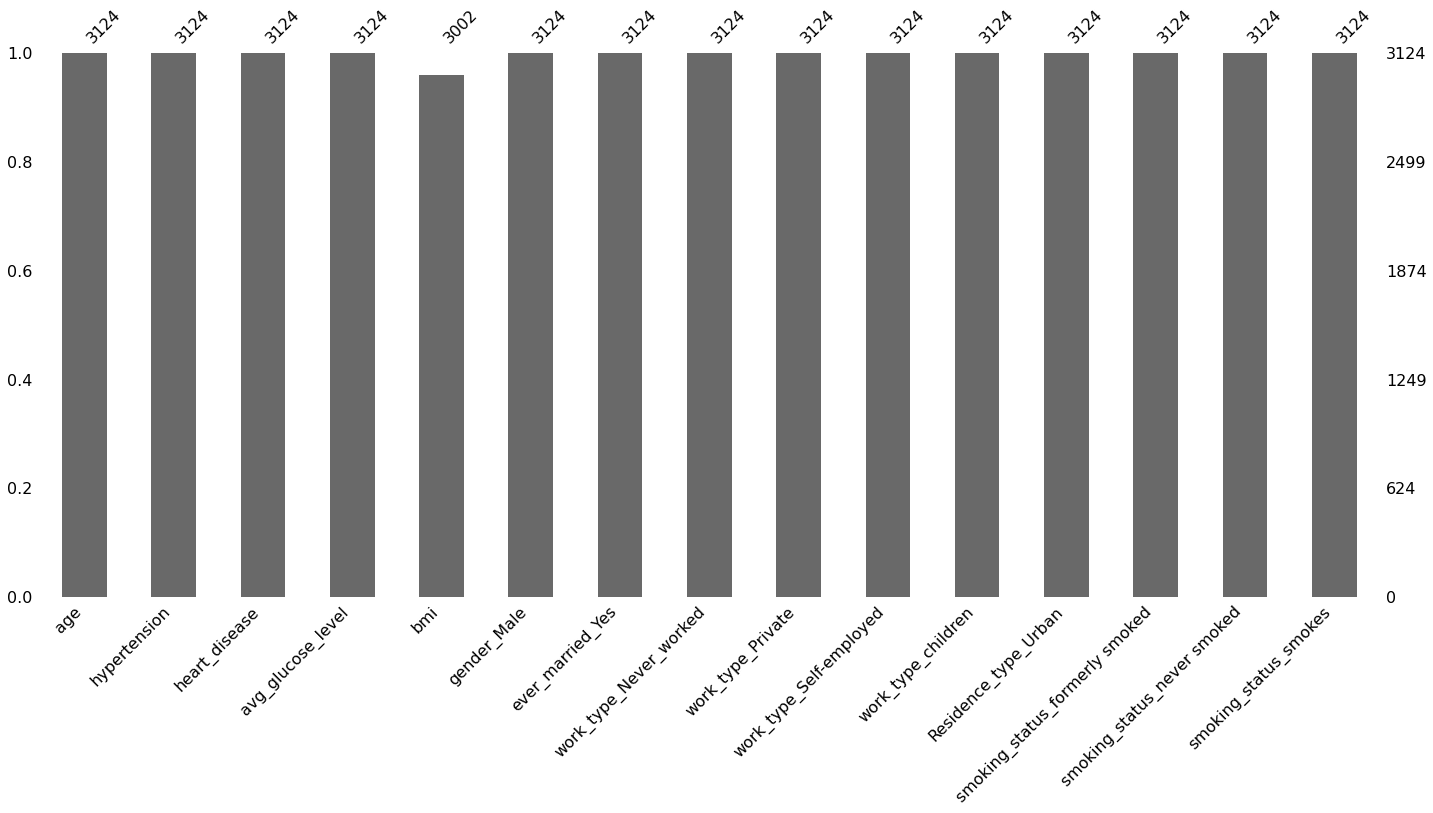

In [30]:
msno.bar(X_train)

<AxesSubplot:>

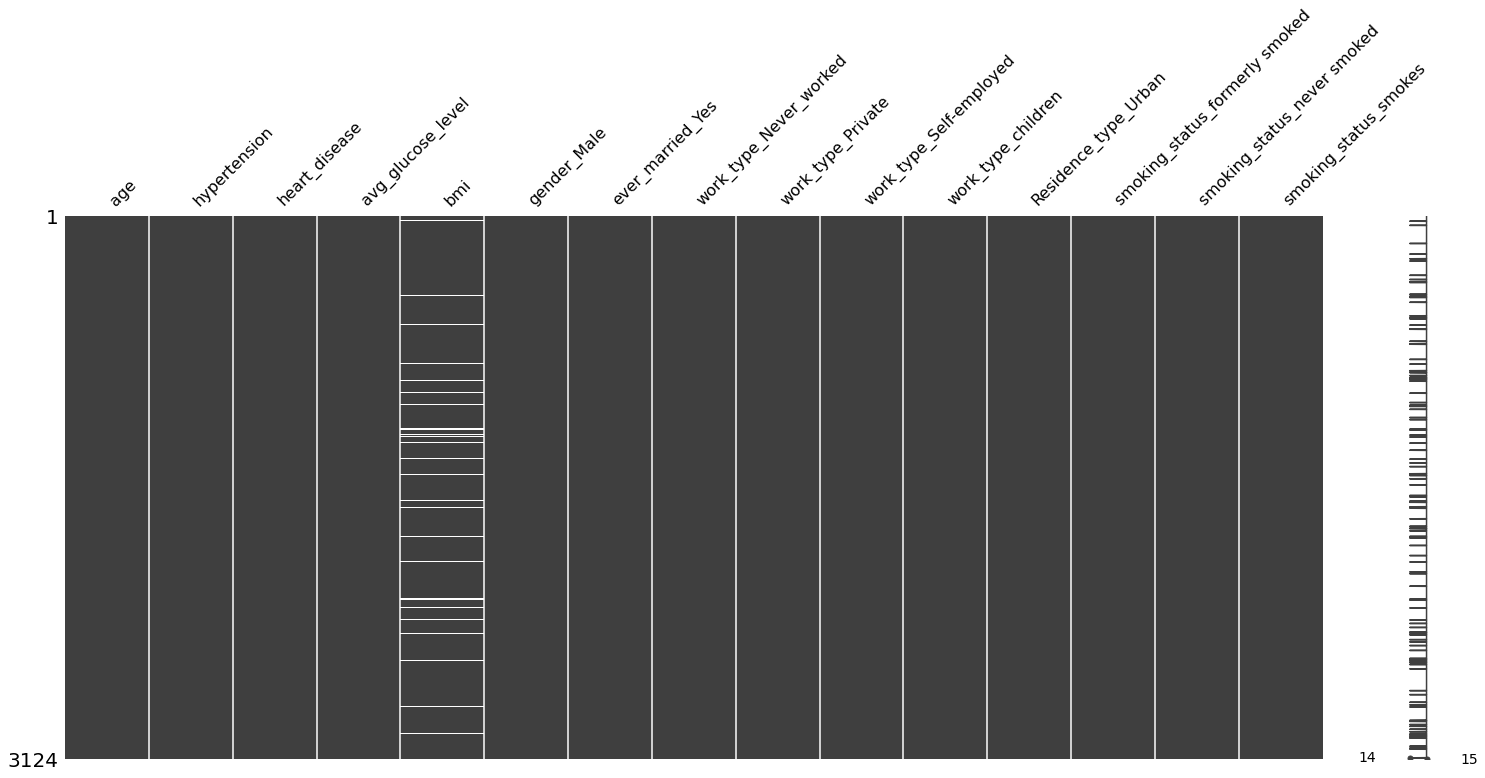

In [31]:
msno.matrix(X_train)

<AxesSubplot:>

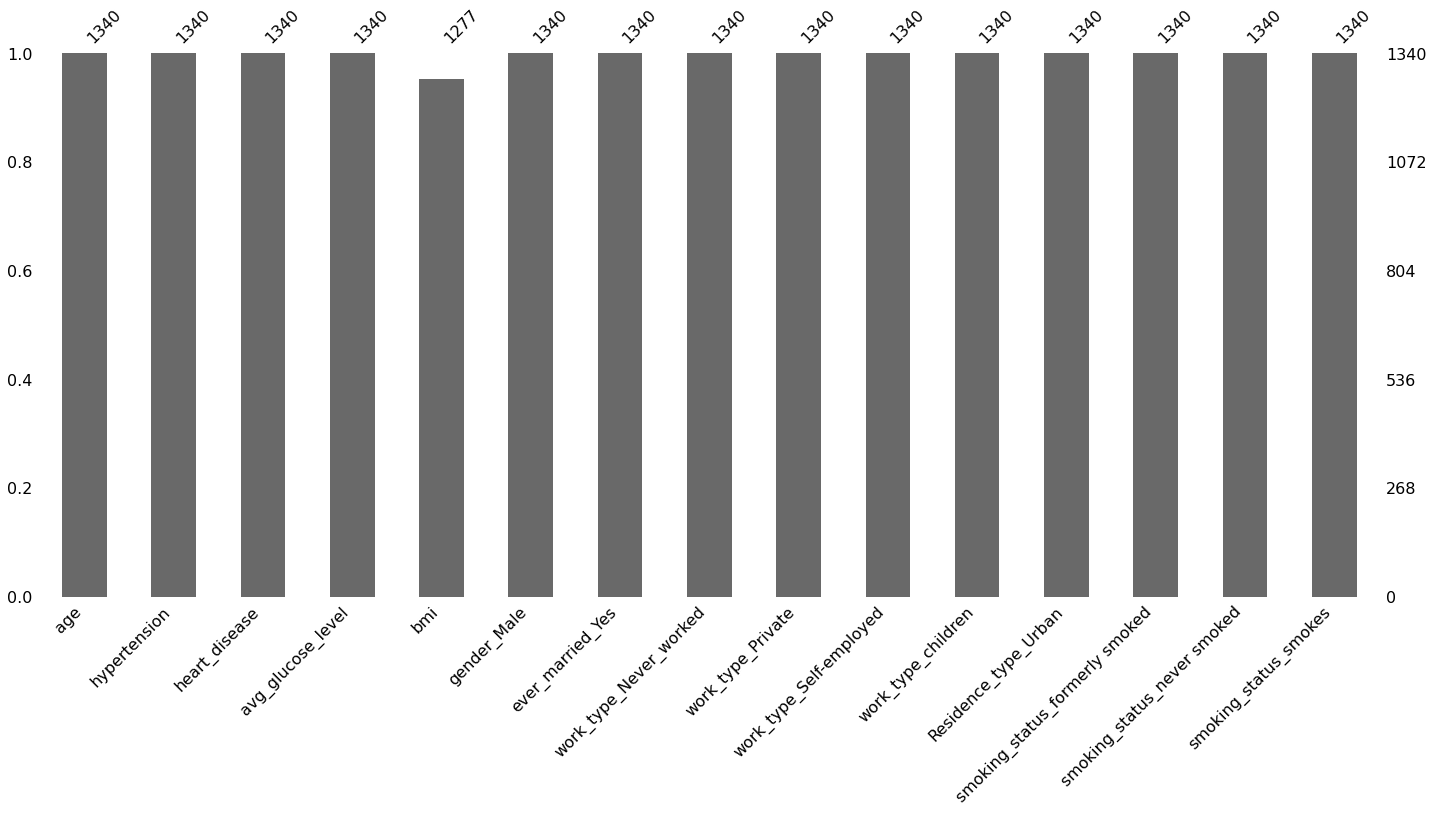

In [32]:
msno.bar(X_test)

In [33]:
X_train.describe()


,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
count,3124.000,3124.000,3124.000,3124.000,3002.000,3124.000,3124.000,3124.000,3124.000,3124.000,3124.000,3124.000,3124.000,3124.000,3124.000
mean,48.284,0.107,0.061,108.259,30.383,0.394,0.747,0.005,0.655,0.182,0.012,0.509,0.192,0.415,0.179
std,18.891,0.309,0.239,47.083,7.486,0.489,0.435,0.074,0.475,0.386,0.111,0.500,0.394,0.493,0.383
min,14.000,0.000,0.000,55.120,11.300,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,33.000,0.000,0.000,77.657,25.200,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,49.000,0.000,0.000,92.925,29.100,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000
75%,63.000,0.000,0.000,116.282,34.000,1.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000
max,82.000,1.000,1.000,267.760,97.600,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


<AxesSubplot:xlabel='bmi'>

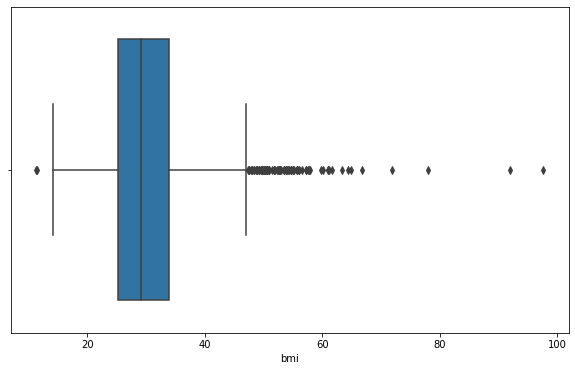

In [34]:
sns.boxplot(X_train.bmi)

Yukarıdaki grafikten de anlaşılacağı üzere median ile doldurmak daha mantıklı olacaktır.

In [35]:
X_train

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
1073,38.000,0,0,162.300,23.600,0,1,0,1,0,0,1,0,1,0
2665,25.000,0,0,103.150,21.000,0,0,0,0,0,0,0,0,0,1
4362,51.000,1,0,69.940,33.300,0,1,0,0,0,0,1,0,0,1
2129,50.000,1,0,220.360,40.900,1,1,0,1,0,0,0,1,0,0
1456,62.000,0,0,78.990,45.500,1,1,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5064,70.000,0,0,193.880,24.300,1,1,0,0,1,0,0,0,0,0
498,15.000,0,0,114.530,29.100,0,0,0,0,0,1,0,0,0,0
3510,15.000,0,0,190.890,22.000,0,0,0,0,0,1,1,0,1,0
4310,45.000,0,0,68.660,25.300,0,1,0,0,0,0,0,0,1,0


In [36]:
from sklearn.impute import SimpleImputer

In [37]:
imputer = SimpleImputer(missing_values=np.nan, strategy="median")

X_train['bmi'] = imputer.fit_transform(X_train['bmi'].values.reshape(-1,1))[:,0]



In [38]:
X_test['bmi'] = imputer.fit_transform(X_test['bmi'].values.reshape(-1,1))[:,0]


In [39]:
print(X_train.isnull().sum(), X_test.isnull().sum())

age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
gender_Male                       0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64 age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
gender_Male                       0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_

In [40]:
X_train['bmi']

1073   23.600
2665   21.000
4362   33.300
2129   40.900
1456   45.500
        ...  
5064   24.300
498    29.100
3510   22.000
4310   25.300
937    22.800
Name: bmi, Length: 3124, dtype: float64

## Scaling

In [41]:
scaler = MinMaxScaler()

In [42]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelling 

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
log_model = LogisticRegression(class_weight='balanced')

In [45]:
log_model.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced')

In [46]:
y_pred = log_model.predict(X_test_scaled)

In [47]:
y_pred_proba = log_model.predict_proba(X_test_scaled)

In [48]:
test_data = pd.concat([X_test, y_test], axis=1)
test_data["pred"] = y_pred
test_data["pred_proba"] = y_pred_proba[:,1]


In [49]:
test_data.sample(10)

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,pred,pred_proba
2836,32.000,0,0,78.300,31.000,1,1,0,1,0,0,1,0,0,0,0,0,0.112
3215,67.000,0,0,260.850,28.800,1,1,0,1,0,0,1,0,0,0,0,1,0.721
3966,28.000,0,0,74.610,32.700,1,0,0,1,0,0,1,0,0,0,0,0,0.103
1533,54.000,0,0,207.790,38.600,0,1,0,1,0,0,1,0,1,0,0,0,0.424
4179,61.000,0,0,73.240,34.900,1,1,0,0,1,0,1,0,1,0,0,0,0.407
2318,51.000,1,0,173.960,31.200,0,1,0,1,0,0,1,1,0,0,0,1,0.628
3666,31.000,0,0,108.640,43.300,0,1,0,0,1,0,0,0,1,0,0,0,0.072
1314,45.000,0,0,97.120,29.200,1,1,0,1,0,0,0,0,1,0,0,0,0.169
4771,17.000,0,0,113.850,22.900,1,0,0,0,1,0,1,0,0,0,0,0,0.051
2411,14.000,0,0,79.360,48.800,1,0,0,1,0,0,1,0,1,0,0,0,0.032


In [50]:
from sklearn.metrics import confusion_matrix, classification_report

In [51]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[888 371]
 [ 14  67]]
              precision    recall  f1-score   support

           0       0.98      0.71      0.82      1259
           1       0.15      0.83      0.26        81

    accuracy                           0.71      1340
   macro avg       0.57      0.77      0.54      1340
weighted avg       0.93      0.71      0.79      1340



In [52]:
from sklearn.model_selection import cross_validate

In [53]:
model = LogisticRegression(class_weight = "balanced")

scores = cross_validate(model, X_train_scaled, y_train, scoring = ['accuracy', 'precision','recall','f1'], cv = 10)
df_scores = pd.DataFrame(scores, index = range(1, 11))
#df_scores
df_scores.mean()[2:]

test_accuracy    0.733
test_precision   0.137
test_recall      0.750
test_f1          0.231
dtype: float64

In [54]:
y_pred_proba = log_model.predict_proba(X_test_scaled)

fp_rate, tp_rate, thresholds = roc_curve(y_test, y_pred_proba[:,1])

optimal_idx = np.argmax(tp_rate - fp_rate)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

test_data = pd.concat([X_test, y_test], axis=1)

test_data["pred_proba"] = y_pred_proba[:,1]

test_data["pred"] = y_pred

test_data["pred2"] = test_data["pred_proba"].apply(lambda x : 1 if x >= optimal_threshold else 0)

y_pred2 = test_data["pred2"]

print(classification_report(y_test,y_pred2))


              precision    recall  f1-score   support

           0       0.99      0.64      0.78      1259
           1       0.14      0.91      0.24        81

    accuracy                           0.65      1340
   macro avg       0.57      0.77      0.51      1340
weighted avg       0.94      0.65      0.74      1340



In [55]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred2))

[[888 371]
 [ 14  67]]
              precision    recall  f1-score   support

           0       0.99      0.64      0.78      1259
           1       0.14      0.91      0.24        81

    accuracy                           0.65      1340
   macro avg       0.57      0.77      0.51      1340
weighted avg       0.94      0.65      0.74      1340

